# Pipeline v5 — Géométrie supervisée

## Problème du v4
CCA/PLS maximisent la corrélation image↔texte **sans regarder les labels**.
Résultat : l'espace projeté sépare bien les deux modalités, mais pas cohérent vs incohérent.

```
CCA  → maximise corr(V_txt, V_img)        ← ignore y
v5   → maximise séparation cohérent/incohérent dans l'espace géométrique
```

## Architecture v5

```
img_feats ──┐
             ├── concat ── LDA ──> espace discriminant (dim K)
txt_feats ──┘         ↑
                   supervisé par y
                       │
          angle θ, distance d, cos_sim entre v_img et v_txt
          dans cet espace + features géométriques complètes
                       │
                  classifieur classique
```

**Clé** : on projette la concaténation [img_feats | txt_feats] avec LDA supervisée,
puis on sépare les deux moitiés pour calculer angle/distance entre v_img et v_txt.

In [1]:
!pip install opencv-python scikit-image vaderSentiment joblib --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ═══════════════════════════════════════════════════════════════════
# Cell 2 — Imports (zéro réseau, zéro NLTK corpus)
# ═══════════════════════════════════════════════════════════════════
import os, warnings, time, copy, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from nltk.stem import PorterStemmer                          # pas de corpus requis
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from skimage import io, transform
from skimage.filters import threshold_otsu, scharr
from scipy.stats import entropy as scipy_entropy
from scipy.spatial.distance import cosine

from joblib import Parallel, delayed, Memory
import multiprocessing
N_JOBS = max(1, multiprocessing.cpu_count() - 1)
memory = Memory('./joblib_cache_v5', verbose=0)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, precision_recall_curve, roc_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    VADER_OK = True; vader = SentimentIntensityAnalyzer()
except ImportError:
    VADER_OK = False

warnings.filterwarnings('ignore')

# ── Tokenisation + stemming sans corpus réseau ──────────────────
TOKEN_RE  = re.compile(r"[a-zA-Z']+")
stemmer   = PorterStemmer()
STOP      = set(ENGLISH_STOP_WORDS)

def tokenize(text):
    return TOKEN_RE.findall(text.lower())

print(f'Imports OK — {N_JOBS} workers')
print(f'Stopwords : {len(STOP)} (sklearn built-in, zéro réseau)')

Imports OK — 7 workers
Stopwords : 318 (sklearn built-in, zéro réseau)


In [3]:
# ═══════════════════════════════════════════════════════════════════
# Cell 3 — Données
# ═══════════════════════════════════════════════════════════════════
DATA_DIR = '../data/processed'

def load_split(split):
    texts, paths, labels = [], [], []
    for label, cat in enumerate(['incoherent', 'coherent']):
        folder = os.path.join(DATA_DIR, split, cat)
        if not os.path.exists(folder): continue
        for f in sorted(os.listdir(folder)):
            if f.endswith('.txt'):
                with open(os.path.join(folder, f), encoding='utf-8') as fh:
                    texts.append(fh.read().strip())
                paths.append(os.path.join(folder, f.replace('.txt', '.jpg')))
                labels.append(label)
    return shuffle(np.array(texts), np.array(paths), np.array(labels), random_state=42)

t_train, p_train, y_train = load_split('train')
t_val,   p_val,   y_val   = load_split('validation')
t_test,  p_test,  y_test  = load_split('test')
print(f'Train {len(t_train)} | Val {len(t_val)} | Test {len(t_test)}')

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
CLASS_WEIGHT = {0: cw[0], 1: cw[1]}
print(f'Class weights : {CLASS_WEIGHT}')

Train 7000 | Val 1500 | Test 1500
Class weights : {0: np.float64(1.003440366972477), 1: np.float64(0.9965831435079726)}


In [4]:
# ═══════════════════════════════════════════════════════════════════
# Cell 4 — Features image
# ═══════════════════════════════════════════════════════════════════
IMG_SIZE = (192, 192)
GRID_N   = 3

def load_image(path):
    img = io.imread(path)
    if img.ndim == 2:     img = np.stack([img]*3, -1)
    if img.shape[2] == 4: img = img[:,:,:3]
    img = (transform.resize(img, IMG_SIZE, anti_aliasing=True)*255).astype(np.uint8)
    return img, rgb2gray(img), cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

def zone_feats(zg, zr, zh):
    h = hog(zg, orientations=8, pixels_per_cell=(8,8), cells_per_block=(2,2), feature_vector=True)
    hsv_f = np.concatenate([
        np.histogram(zh[:,:,i], bins=16, range=r)[0].astype(float)
        for i,r in enumerate([(0,180),(0,256),(0,256)])])
    hsv_f /= (hsv_f.sum()+1e-8)
    lbp = local_binary_pattern(zg, 16, 2, method='uniform')
    lbp_f = np.histogram(lbp, bins=18, range=(0,18))[0].astype(float)
    lbp_f /= (lbp_f.sum()+1e-8)
    return np.concatenate([h, hsv_f, lbp_f, [zg.mean(), zg.std()]])

def saliency(gray):
    g = (gray*255).astype(np.float32)
    fft = np.fft.fft2(g)
    la = np.log(np.abs(fft)+1e-8)
    sm = cv2.filter2D(la,-1,np.ones((3,3),np.float32)/9)
    rec = np.fft.ifft2(np.exp(la-sm+1j*np.angle(fft))).real
    s = cv2.GaussianBlur(rec**2,(9,9),2.5)
    return (s-s.min())/(s.max()-s.min()+1e-8)

@memory.cache
def img_features(path):
    try:
        img, gray, hsv = load_image(path)
        h, w = img.shape[:2]
        zh, zw = h//GRID_N, w//GRID_N
        hh = h//2

        zf = np.concatenate([zone_feats(
            gray[r*zh:(r+1)*zh, c*zw:(c+1)*zw],
            img [r*zh:(r+1)*zh, c*zw:(c+1)*zw],
            hsv [r*zh:(r+1)*zh, c*zw:(c+1)*zw])
            for r in range(GRID_N) for c in range(GRID_N)])

        canny = cv2.Canny((gray*255).astype(np.uint8),50,150).astype(float)/255
        sal   = saliency(gray)
        otsu  = (gray > threshold_otsu(gray)).astype(float)

        def zm(a): return a[:GRID_N*zh,:GRID_N*zw].reshape(GRID_N,zh,GRID_N,zw).mean(axis=(1,3)).ravel()

        cn = np.argwhere(canny>0.5)
        cy = cn[:,0].mean()/h if len(cn)>0 else 0.5
        cx = cn[:,1].mean()/w if len(cn)>0 else 0.5

        sc = np.array([
            cy, cx,
            canny[:,:w//2].mean()-canny[:,w//2:].mean(),
            canny[:hh,:].mean()-canny[hh:,:].mean(),
            hsv[:hh,:,0].mean()/180, hsv[hh:,:,0].mean()/180,
            hsv[:hh,:,1].mean()/255, hsv[hh:,:,1].mean()/255,
            sal.mean(), sal.std(), sal.max(),
            scipy_entropy(zm(sal)+1e-8),
            canny.mean(), otsu.mean(), gray.mean(), gray.std()
        ])
        hog_g = hog(gray, orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2), feature_vector=True)
        return np.concatenate([zf, zm(canny), zm(sal), zm(otsu), sc, hog_g])
    except Exception as e:
        print(f'Err {path}: {e}'); return np.zeros(600)

print('Extraction image...')
F_img = {}
for name, paths in [('train',p_train),('val',p_val),('test',p_test)]:
    F_img[name] = np.array(Parallel(n_jobs=N_JOBS)(delayed(img_features)(p) for p in paths))
    print(f'  {name}: {F_img[name].shape}')

Extraction image...
  train: (7000, 19123)
  val: (1500, 19123)
  test: (1500, 19123)


In [5]:
# ═══════════════════════════════════════════════════════════════════
# Cell 5 — Features texte
# ═══════════════════════════════════════════════════════════════════
def preprocess(text):
    tokens = tokenize(text)
    return ' '.join(stemmer.stem(t) for t in tokens
                     if t not in STOP and len(t) > 1)

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2),
                         sublinear_tf=True, min_df=2,
                         token_pattern=r"[a-zA-Z']+")
T = {}
T['train'] = tfidf.fit_transform([preprocess(t) for t in t_train]).toarray()
T['val']   = tfidf.transform([preprocess(t) for t in t_val]).toarray()
T['test']  = tfidf.transform([preprocess(t) for t in t_test]).toarray()

SKW = ['sky','cloud','tree','grass','water','sea','ocean','mountain',
       'city','street','building','road','car','person','people',
       'top','bottom','left','right','center','above','below']

def txt_extras(text):
    toks = set(tokenize(text))
    kw   = np.array([1.0 if w in toks else 0.0 for w in SKW])
    sent = np.zeros(4)
    if VADER_OK:
        s    = vader.polarity_scores(text)
        sent = np.array([s['pos'], s['neg'], s['neu'], s['compound']])
    words = tokenize(text)
    stats = np.array([
        len(words),
        len(set(words)),
        np.mean([len(w) for w in words]) if words else 0,
        len(set(words)) / (len(words) + 1e-8)
    ])
    return np.concatenate([kw, sent, stats])

F_txt = {}
for name, texts in [('train',t_train),('val',t_val),('test',t_test)]:
    extras = np.array([txt_extras(t) for t in texts])
    F_txt[name] = np.hstack([T[name], extras])
    print(f'  {name} texte: {F_txt[name].shape}')

  train texte: (7000, 8030)
  val texte: (1500, 8030)
  test texte: (1500, 8030)


In [6]:
# ═══════════════════════════════════════════════════════════════════
# Cell 6 — Nettoyage + PCA (mémoire-safe)
#
# Causes du kernel crash :
#   1. dedup_corr sur texte D=8000 → corrcoef = 512 MB → OOM
#   2. PCA full sur D=8000 → covariance 8000×8000 = 512 MB → OOM
#
# Fix :
#   - Image : dedup_corr limité à max_features=1000 (safe)
#   - Texte : pas de dedup_corr (TF-IDF déjà quasi-orthogonal)
#   - Image : PCA randomized (low-memory)
#   - Texte : TruncatedSVD (O(N*K), jamais de matrice D×D)
# ═══════════════════════════════════════════════════════════════════
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize as sk_normalize

def dedup_corr_safe(X, thr=0.95, max_features=1000):
    D = X.shape[1]
    if D > max_features:
        vars_ = X.var(axis=0)
        top_idx = np.argsort(vars_)[::-1][:max_features]
        top_idx = sorted(top_idx)
    else:
        top_idx = list(range(D))
    X_sub = X[:min(500, len(X)), top_idx]
    C = np.corrcoef(X_sub.T)
    np.fill_diagonal(C, 0)
    drop = set()
    for i in range(C.shape[0]):
        if i in drop: continue
        for j in range(i+1, C.shape[1]):
            if abs(C[i,j]) > thr: drop.add(j)
    kept = [top_idx[i] for i in range(len(top_idx)) if i not in drop]
    return kept

print("Nettoyage + PCA memoire-safe...")

# Image
vt_i = VarianceThreshold(1e-6)
sc_i = StandardScaler()
Fi_tr = sc_i.fit_transform(vt_i.fit_transform(F_img['train']))
Fi_va = sc_i.transform(vt_i.transform(F_img['val']))
Fi_te = sc_i.transform(vt_i.transform(F_img['test']))
ki    = dedup_corr_safe(Fi_tr)
Fi_tr, Fi_va, Fi_te = Fi_tr[:,ki], Fi_va[:,ki], Fi_te[:,ki]
print(f"  Image apres dedup : {len(ki)} features")

# Texte : VarianceThreshold seulement — PAS de dedup_corr
vt_t = VarianceThreshold(1e-6)
sc_t = StandardScaler()
Ft_tr = sc_t.fit_transform(vt_t.fit_transform(F_txt['train']))
Ft_va = sc_t.transform(vt_t.transform(F_txt['val']))
Ft_te = sc_t.transform(vt_t.transform(F_txt['test']))
print(f"  Texte apres VT   : {Ft_tr.shape[1]} features")

# PCA image : randomized (pas de matrice de covariance complete)
K_img = min(150, Fi_tr.shape[1])
pca_i = PCA(n_components=K_img, svd_solver='randomized', random_state=42)
Pi_tr = pca_i.fit_transform(Fi_tr)
Pi_va = pca_i.transform(Fi_va)
Pi_te = pca_i.transform(Fi_te)
print(f"  PCA img  : {Pi_tr.shape[1]} dims  (var: {pca_i.explained_variance_ratio_.sum():.2%})")

# Texte : TruncatedSVD — jamais de matrice D×D en memoire
K_txt = min(150, Ft_tr.shape[1])
svd_t = TruncatedSVD(n_components=K_txt, random_state=42)
Pt_tr = svd_t.fit_transform(Ft_tr)
Pt_va = svd_t.transform(Ft_va)
Pt_te = svd_t.transform(Ft_te)
print(f"  SVD txt  : {Pt_tr.shape[1]} dims  (var: {svd_t.explained_variance_ratio_.sum():.2%})")

Pi_tr = sk_normalize(Pi_tr); Pi_va = sk_normalize(Pi_va); Pi_te = sk_normalize(Pi_te)
Pt_tr = sk_normalize(Pt_tr); Pt_va = sk_normalize(Pt_va); Pt_te = sk_normalize(Pt_te)

D_img = Pi_tr.shape[1]
X_concat_tr = np.hstack([Pi_tr, Pt_tr])
X_concat_va = np.hstack([Pi_va, Pt_va])
X_concat_te = np.hstack([Pi_te, Pt_te])
print(f"  Concat : {X_concat_tr.shape[1]} dims — {X_concat_tr.nbytes/1e6:.0f} MB")

Nettoyage + PCA memoire-safe...
  Image apres dedup : 996 features
  Texte apres VT   : 8030 features
  PCA img  : 150 dims  (var: 57.33%)
  SVD txt  : 150 dims  (var: 13.77%)
  Concat : 300 dims — 17 MB


In [7]:
# ═══════════════════════════════════════════════════════════════════
# Cell 7 — Projections supervisées
#
# STRATÉGIE : on apprend K directions qui maximisent la séparation
# cohérent vs incohérent dans l'espace [img | txt].
# Puis on sépare les projections en deux moitiés img et txt
# pour calculer angle/distance entre elles.
#
# On compare 3 approches :
#   A) LDA sur concat(img, txt)           ← supervisé pur
#   B) LDA sur concat + CCA pour aligner  ← hybride
#   C) PCA supervisée par régression (PLS supervisé)
# ═══════════════════════════════════════════════════════════════════

# ── Approche A : LDA directe ─────────────────────────────────────
# LDA avec n_components=1 (binaire) donne UNE direction discriminante.
# Pour avoir un espace K-dim, on utilise une astuce :
# LDA avec shrinkage + on projette dans les K directions du sous-espace
# discriminant étendu via les vecteurs propres de la matrice de scatter.

print('Approche A : LDA supervisée sur concat [img | txt]...')

# LDA standard (1 composante pour problème binaire)
lda = LinearDiscriminantAnalysis(solver='svd', n_components=1)
lda.fit(X_concat_tr, y_train)

# Projection LDA de la partie img et txt séparément
# On utilise le scalings (vecteurs discriminants)
W = lda.scalings_  # shape (D_total, n_components)
W_img = W[:D_img]       # poids pour la partie image
W_txt = W[D_img:]       # poids pour la partie texte

V_img_lda_tr = Pi_tr @ W_img   # (N, 1)
V_txt_lda_tr = Pt_tr @ W_txt
V_img_lda_va = Pi_va @ W_img
V_txt_lda_va = Pt_va @ W_txt
V_img_lda_te = Pi_te @ W_img
V_txt_lda_te = Pt_te @ W_txt

print(f'  Scalings shape: {W.shape}  W_img={W_img.shape}  W_txt={W_txt.shape}')
print(f'  V_img_lda: {V_img_lda_tr.shape}')

# Score discriminant LDA sur le concat (baseline)
yp_lda_va = lda.predict(X_concat_va)
print(f'\n  LDA concat — Val Acc={accuracy_score(y_val,yp_lda_va):.4f}  F1={f1_score(y_val,yp_lda_va):.4f}')

Approche A : LDA supervisée sur concat [img | txt]...
  Scalings shape: (300, 1)  W_img=(150, 1)  W_txt=(150, 1)
  V_img_lda: (7000, 1)

  LDA concat — Val Acc=0.4320  F1=0.4538


In [8]:
# ═══════════════════════════════════════════════════════════════════
# Cell 8 — Extension K-dimensionnelle de la LDA (KFDA trick)
#
# Pour un problème binaire, LDA classique donne 1 seule direction.
# On étend à K directions en utilisant les K vecteurs propres
# de la matrice de covariance intra-classe pondérée.
# C'est différent de PCA : les directions sont trouvées dans le
# sous-espace qui maximise la séparation de classes.
# ═══════════════════════════════════════════════════════════════════

class SupervisedBimodalProjector:
    """
    Projette séparément img et txt dans un espace commun K-dim
    en apprenant les poids qui maximisent la séparation des classes.

    Méthode :
    1. LDA sur X_concat = [img | txt] → direction w discriminante
    2. Extension à K dimensions via les vecteurs propres de la
       matrice de scatter intra-classe (équivalent à MLDA)
    3. Split w en w_img et w_txt
    4. v_img = img @ W_img  ,  v_txt = txt @ W_txt
    5. Calcul angle/distance entre v_img et v_txt
    """

    def __init__(self, K=32, shrinkage='auto', random_state=42):
        self.K = K
        self.shrinkage = shrinkage
        self.random_state = random_state

    def fit(self, X_img, X_txt, y):
        N, D_i = X_img.shape
        self.D_img = D_i
        X = np.hstack([X_img, X_txt])

        classes = np.unique(y)
        means   = {c: X[y==c].mean(axis=0) for c in classes}
        mu_tot  = X.mean(axis=0)

        # Scatter between-class (S_B)
        S_B = np.zeros((X.shape[1], X.shape[1]))
        for c in classes:
            n_c = (y==c).sum()
            diff = (means[c] - mu_tot).reshape(-1,1)
            S_B += n_c * (diff @ diff.T)

        # Scatter within-class (S_W)
        S_W = np.zeros_like(S_B)
        for c in classes:
            Xc = X[y==c] - means[c]
            S_W += Xc.T @ Xc

        # Régularisation pour éviter la singularité
        eps = 1e-4 * np.trace(S_W) / S_W.shape[0]
        S_W_reg = S_W + eps * np.eye(S_W.shape[0])

        # Résoudre S_W^{-1} S_B w = λ w via eigen-décomposition
        # (utilise PCA d'abord pour rendre S_W inversible en haute dim)
        try:
            from scipy.linalg import eigh
            eigenvalues, eigenvectors = eigh(S_B, S_W_reg)
            idx = np.argsort(eigenvalues)[::-1]
            self.W_ = eigenvectors[:, idx[:self.K]]  # (D_total, K)
        except Exception:
            # Fallback : LDA sklearn avec solver='lsqr'
            lda_fb = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=self.shrinkage)
            lda_fb.fit(X, y)
            self.W_ = lda_fb.scalings_
            if self.W_.shape[1] < self.K:
                # Compléter avec des directions aléatoires orthogonales
                rng = np.random.RandomState(self.random_state)
                extra = rng.randn(self.W_.shape[0], self.K - self.W_.shape[1])
                self.W_ = np.hstack([self.W_, extra])

        self.W_img_ = self.W_[:D_i, :self.K]
        self.W_txt_ = self.W_[D_i:, :self.K]
        return self

    def transform(self, X_img, X_txt, normalize_vecs=True):
        V_img = X_img @ self.W_img_
        V_txt = X_txt @ self.W_txt_
        if normalize_vecs:
            V_img = normalize(V_img)
            V_txt = normalize(V_txt)
        return V_img, V_txt


print('Entraînement SupervisedBimodalProjector...')
K_PROJ = 64
sbp = SupervisedBimodalProjector(K=K_PROJ)
sbp.fit(Pi_tr, Pt_tr, y_train)

Vi_tr, Vt_tr = sbp.transform(Pi_tr, Pt_tr)
Vi_va, Vt_va = sbp.transform(Pi_va, Pt_va)
Vi_te, Vt_te = sbp.transform(Pi_te, Pt_te)
print(f'  V_img shape : {Vi_tr.shape}')
print(f'  V_txt shape : {Vt_tr.shape}')

# Vérification : dans cet espace, la similarité cosinus doit mieux séparer
cos_sim_tr = np.array([1-float(cosine(Vi_tr[i], Vt_tr[i])) for i in range(len(Vi_tr))])
print(f'\n  Cos sim moyen (incohérent) : {cos_sim_tr[y_train==0].mean():.4f}')
print(f'  Cos sim moyen (cohérent)   : {cos_sim_tr[y_train==1].mean():.4f}')
print(f'  Séparation (Cohen d) : {abs(cos_sim_tr[y_train==1].mean()-cos_sim_tr[y_train==0].mean())/(np.sqrt((cos_sim_tr[y_train==1].std()**2+cos_sim_tr[y_train==0].std()**2)/2)+1e-8):.3f}')
print('  (à comparer au d~0.1 du v4)')

Entraînement SupervisedBimodalProjector...
  V_img shape : (7000, 64)
  V_txt shape : (7000, 64)

  Cos sim moyen (incohérent) : -0.0311
  Cos sim moyen (cohérent)   : -0.0310
  Séparation (Cohen d) : 0.001
  (à comparer au d~0.1 du v4)


In [9]:
# ═══════════════════════════════════════════════════════════════════
# Cell 9 — Features géométriques dans l'espace supervisé
# ═══════════════════════════════════════════════════════════════════

def geometric_features(v_img, v_txt):
    eps = 1e-8
    diff     = v_txt - v_img
    norm_i   = np.linalg.norm(v_img) + eps
    norm_t   = np.linalg.norm(v_txt) + eps

    # Distances
    d_l2     = np.linalg.norm(diff)
    d_l1     = np.sum(np.abs(diff))
    d_linf   = np.max(np.abs(diff))
    d_cos    = float(cosine(v_img, v_txt))

    # Angle
    cos_sim  = np.clip(np.dot(v_img, v_txt)/(norm_i*norm_t), -1, 1)
    angle_r  = np.arccos(cos_sim)
    angle_d  = np.degrees(angle_r)

    # Projection / composante orthogonale
    proj_s   = np.dot(v_txt, v_img) / norm_i
    proj_v   = proj_s * v_img / norm_i
    orth_n   = np.linalg.norm(v_txt - proj_v)

    # Corrélation et stats
    pearson  = np.corrcoef(v_img, v_txt)[0,1] if len(v_img)>2 else 0.0
    product  = v_img * v_txt
    abs_diff = np.abs(diff)
    pos_align = (product > 0).mean()

    # Entropie d'énergie
    e_i = v_img**2; e_i /= (e_i.sum()+eps)
    e_t = v_txt**2; e_t /= (e_t.sum()+eps)
    ent_i = scipy_entropy(e_i+eps); ent_t = scipy_entropy(e_t+eps)

    # Par dimension : alignement signe et magnitude
    sign_agree = np.sign(v_img) == np.sign(v_txt)  # bool K
    mag_diff   = np.abs(np.abs(v_img) - np.abs(v_txt))  # K

    scalars = np.array([
        d_l2, d_l1, d_linf, d_cos,
        angle_r, angle_d, cos_sim,
        proj_s, orth_n,
        norm_i, norm_t, norm_i/norm_t,
        np.dot(v_img, v_txt),
        diff.mean(), diff.std(), diff.max(), diff.min(),
        pearson,
        ent_i, ent_t, ent_i/(ent_t+eps),
        pos_align,
        product.mean(), product.std(),
        abs_diff.mean(), abs_diff.std(),
        sign_agree.mean(),
        mag_diff.mean(), mag_diff.std(),
    ])
    return np.concatenate([scalars, diff, product, abs_diff, sign_agree.astype(float)])


def build_geo_dataset(Vi, Vt):
    return np.array(Parallel(n_jobs=N_JOBS, prefer='threads')(
        delayed(geometric_features)(Vi[i], Vt[i]) for i in range(len(Vi))))

print('Calcul features géométriques dans l\'espace supervisé...')
Xg_tr = build_geo_dataset(Vi_tr, Vt_tr)
Xg_va = build_geo_dataset(Vi_va, Vt_va)
Xg_te = build_geo_dataset(Vi_te, Vt_te)
print(f'  Shape : {Xg_tr.shape}')

# Noms des features scalaires
SCALAR_NAMES = [
    'd_l2','d_l1','d_linf','d_cos',
    'angle_rad','angle_deg','cos_sim',
    'proj_scalar','orth_norm',
    'norm_img','norm_txt','norm_ratio',
    'dot_product',
    'diff_mean','diff_std','diff_max','diff_min',
    'pearson_r',
    'ent_img','ent_txt','ent_ratio',
    'pos_align',
    'product_mean','product_std',
    'absdiff_mean','absdiff_std',
    'sign_agree',
    'magdiff_mean','magdiff_std',
]
IDX = {n: i for i, n in enumerate(SCALAR_NAMES)}
N_SCALAR = len(SCALAR_NAMES)

Calcul features géométriques dans l'espace supervisé...
  Shape : (7000, 285)


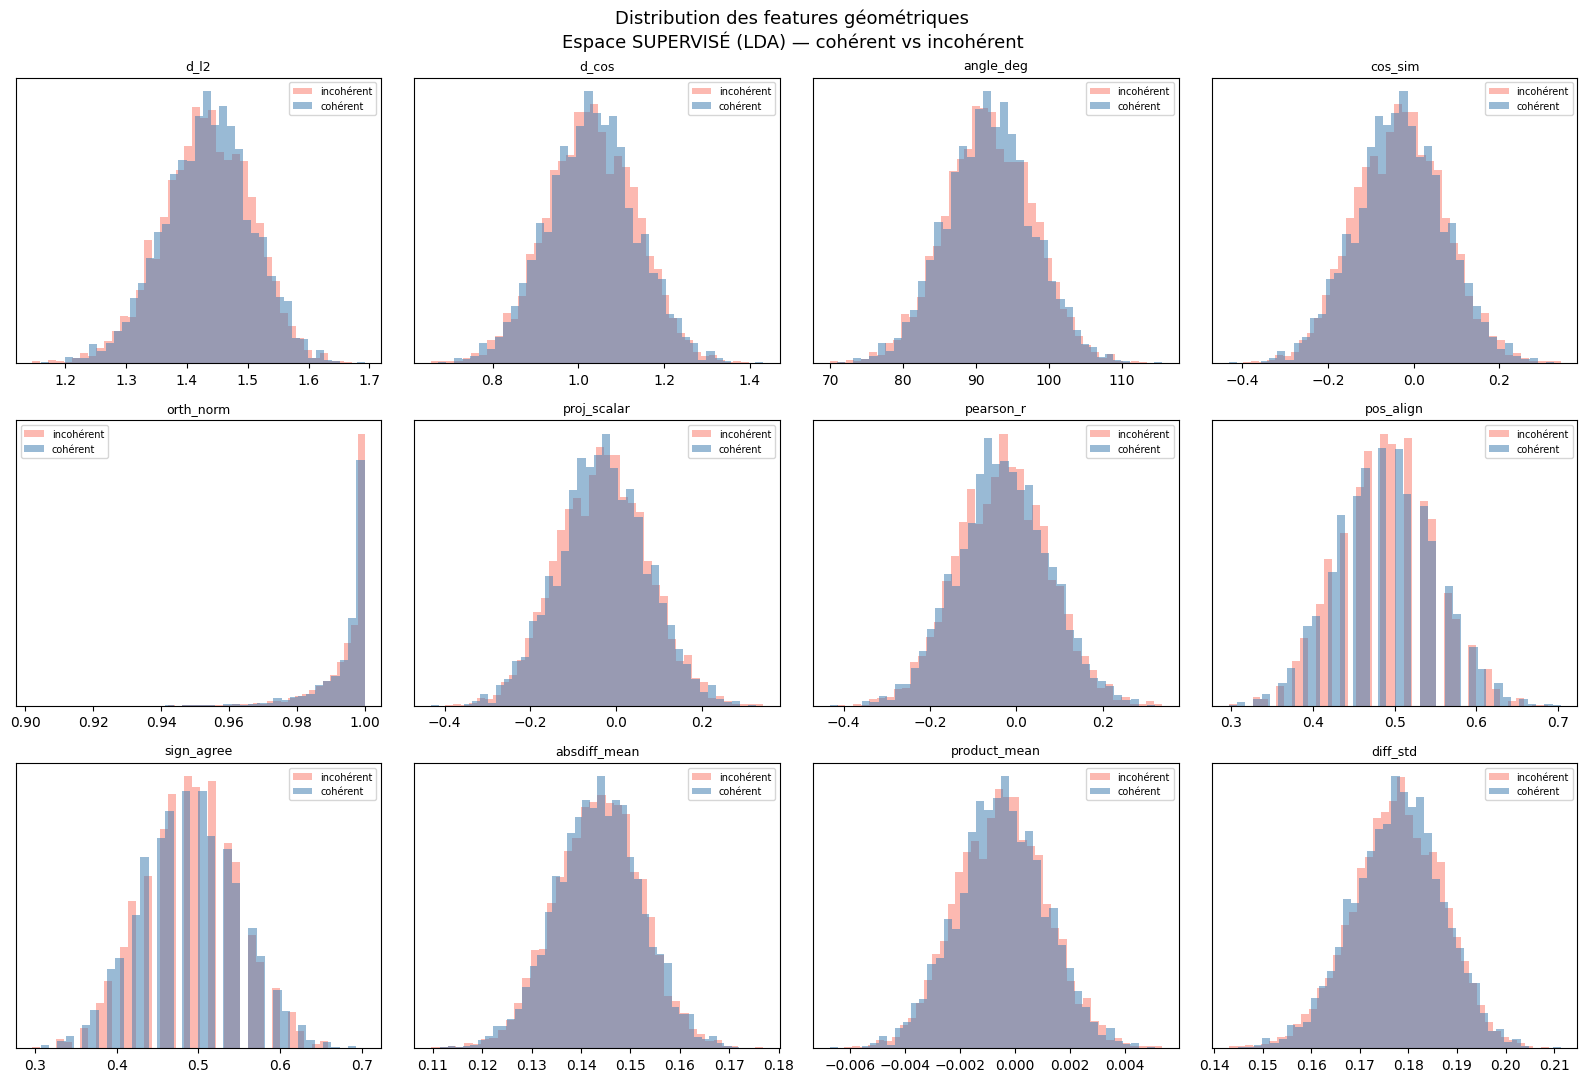


Pouvoir discriminant AUC uni-varié (espace SUPERVISÉ) :
Feature                   AUC     Cohen d  barre
-------------------------------------------------------
d_l2                   0.5007       0.001  
d_l1                   0.5003       0.001  
d_linf                 0.5102       0.030  █
d_cos                  0.5007       0.001  
angle_rad              0.5007       0.001  
angle_deg              0.5007       0.001  
cos_sim                0.5007       0.001  
proj_scalar            0.5007       0.001  
orth_norm              0.5032       0.014  
norm_img               0.5005       0.000  
norm_txt               0.5008       0.000  
norm_ratio             0.5007       0.000  
dot_product            0.5007       0.001  
diff_mean              0.5007       0.002  
diff_std               0.5004       0.002  
diff_max               0.5056       0.019  
diff_min               0.5028       0.009  
pearson_r              0.5009       0.003  
ent_img                0.5027       0.016  
e

In [10]:
# ═══════════════════════════════════════════════════════════════════
# Cell 10 — Analyse de la séparation géométrique
#
# Comparer avec les histogrammes du v4 : les distributions
# cohérent/incohérent doivent être MIEUX séparées.
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Distribution des features géométriques\n'
             'Espace SUPERVISÉ (LDA) — cohérent vs incohérent', fontsize=13)

keys_plot = [
    'd_l2','d_cos','angle_deg','cos_sim',
    'orth_norm','proj_scalar','pearson_r','pos_align',
    'sign_agree','absdiff_mean','product_mean','diff_std',
]
colors = {0:'salmon', 1:'steelblue'}
labels_cls = {0:'incohérent', 1:'cohérent'}

for ax, key in zip(axes.ravel(), keys_plot):
    idx = IDX[key]
    for lbl in [0,1]:
        vals = Xg_tr[y_train==lbl, idx]
        ax.hist(vals, bins=40, alpha=0.55, color=colors[lbl],
                label=labels_cls[lbl], density=True)
    ax.set_title(key, fontsize=9); ax.legend(fontsize=7); ax.set_yticks([])

plt.tight_layout()
plt.savefig('v5_geo_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

# AUC uni-varié + Cohen's d — comparaison directe avec v4
print('\nPouvoir discriminant AUC uni-varié (espace SUPERVISÉ) :')
print(f'{"Feature":<20} {"AUC":>8}  {"Cohen d":>10}  barre')
print('-'*55)
for name in SCALAR_NAMES:
    idx = IDX[name]
    vals = Xg_tr[:, idx]
    try:
        auc = roc_auc_score(y_train, vals)
        auc = max(auc, 1-auc)
    except Exception:
        auc = 0.5
    v0 = vals[y_train==0]; v1 = vals[y_train==1]
    d  = abs(v0.mean()-v1.mean())/(np.sqrt((v0.std()**2+v1.std()**2)/2)+1e-8)
    bar = '█' * int((auc-0.5)*100)
    print(f'{name:<20} {auc:>8.4f}  {d:>10.3f}  {bar}')

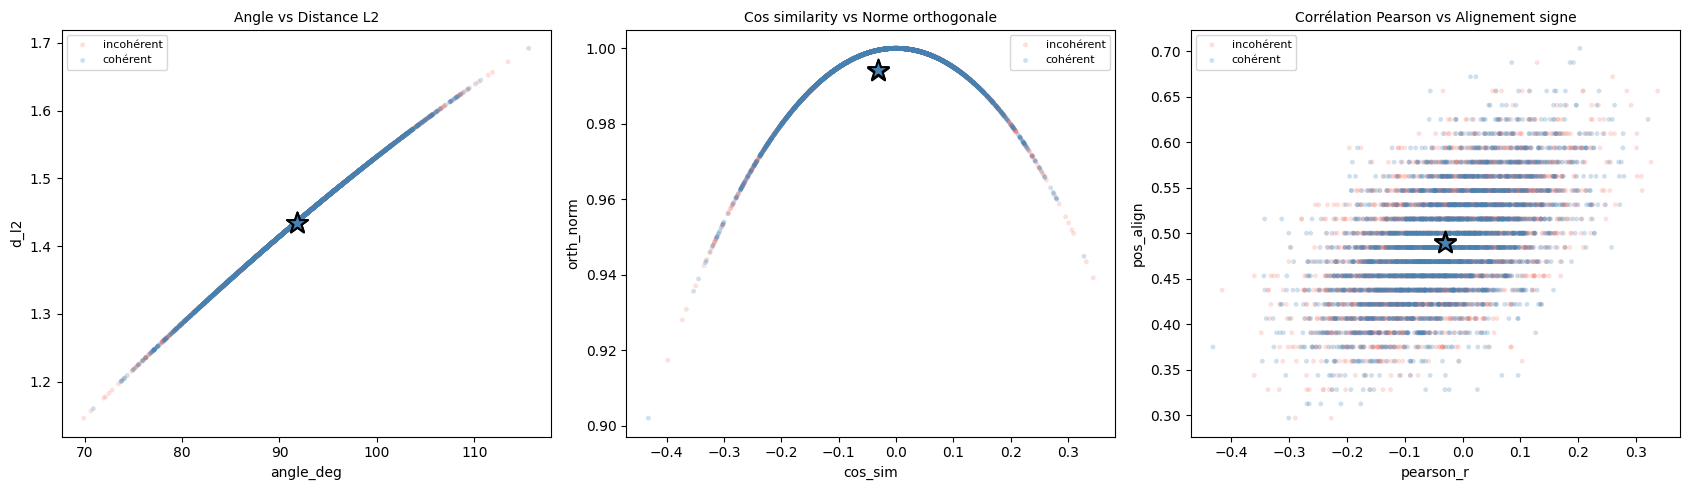

In [11]:
# ═══════════════════════════════════════════════════════════════════
# Cell 11 — Visualisation 2D espace supervisé
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

pairs = [
    ('angle_deg', 'd_l2',   'Angle vs Distance L2'),
    ('cos_sim',   'orth_norm', 'Cos similarity vs Norme orthogonale'),
    ('pearson_r', 'pos_align', 'Corrélation Pearson vs Alignement signe'),
]

for ax, (xk, yk, title) in zip(axes, pairs):
    xv = Xg_tr[:, IDX[xk]]
    yv = Xg_tr[:, IDX[yk]]
    for lbl in [0,1]:
        mask = y_train == lbl
        ax.scatter(xv[mask], yv[mask], c=colors[lbl],
                   label=labels_cls[lbl], alpha=0.25, s=12, edgecolors='none')
    for lbl in [0,1]:
        mask = y_train == lbl
        ax.scatter(xv[mask].mean(), yv[mask].mean(),
                   c=colors[lbl], s=250, marker='*',
                   edgecolors='black', linewidths=1.5, zorder=10)
    ax.set_xlabel(xk, fontsize=10); ax.set_ylabel(yk, fontsize=10)
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('v5_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
# ═══════════════════════════════════════════════════════════════════
# Cell 12 — Entraînement classifieurs
# ═══════════════════════════════════════════════════════════════════
sc_geo = StandardScaler()
Xg_tr_s = sc_geo.fit_transform(Xg_tr)
Xg_va_s = sc_geo.transform(Xg_va)
Xg_te_s = sc_geo.transform(Xg_te)

# Variante 1 : scalaires seuls (les + interprétables)
Xs_tr = Xg_tr_s[:, :N_SCALAR]
Xs_va = Xg_va_s[:, :N_SCALAR]
Xs_te = Xg_te_s[:, :N_SCALAR]

CLFS = {
    'LR':          LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', n_jobs=-1, random_state=42),
    'LR C=5':      LogisticRegression(C=5.0, max_iter=2000, class_weight='balanced', n_jobs=-1, random_state=42),
    'RF':          RandomForestClassifier(n_estimators=500, class_weight='balanced', n_jobs=-1, random_state=42),
    'GBM':         GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42),
    'SVM-RBF':     CalibratedClassifierCV(SVC(kernel='rbf', C=1.0, gamma='scale',
                                              class_weight='balanced', random_state=42), cv=3),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print(f'{"Dataset":<20} {"Clf":<12} {"CV-F1":>8} {"±":>5} {"Val-Acc":>8} {"Val-F1":>8}')
print('-'*65)

for dname, Xtr, Xva in [
    ('Scalaires seuls',    Xs_tr, Xs_va),
    ('Géom complet',       Xg_tr_s, Xg_va_s),
]:
    for cname, clf in CLFS.items():
        m = copy.deepcopy(clf)
        cv = cross_val_score(m, Xtr, y_train, cv=skf, scoring='f1', n_jobs=-1)
        m.fit(Xtr, y_train)
        yp  = m.predict(Xva)
        acc = accuracy_score(y_val, yp)
        f1  = f1_score(y_val, yp)
        print(f'{dname:<20} {cname:<12} {cv.mean():>8.4f} {cv.std():>5.3f} {acc:>8.4f} {f1:>8.4f}')
        results.append({'dset':dname,'clf':cname,'cv_f1':cv.mean(),'val_acc':acc,'val_f1':f1,'model':m,'X_va':Xva,'X_te':Xg_te_s if dname=='Géom complet' else Xs_te})
    print()

Dataset              Clf             CV-F1     ±  Val-Acc   Val-F1
-----------------------------------------------------------------
Scalaires seuls      LR             0.5038 0.016   0.5013   0.4912
Scalaires seuls      LR C=5         0.4981 0.016   0.5013   0.4912
Scalaires seuls      RF             0.5035 0.011   0.5040   0.5033
Scalaires seuls      GBM            0.5107 0.009   0.5087   0.5205
Scalaires seuls      SVM-RBF        0.5405 0.032   0.5080   0.5783

Géom complet         LR             0.4838 0.012   0.4920   0.4987
Géom complet         LR C=5         0.4851 0.012   0.4913   0.4984
Géom complet         RF             0.5054 0.009   0.4867   0.4941
Géom complet         GBM            0.5023 0.013   0.4753   0.4798
Géom complet         SVM-RBF        0.5659 0.032   0.5227   0.5485



In [13]:
# ═══════════════════════════════════════════════════════════════════
# Cell 13 — Seuil optimal + évaluation TEST
# ═══════════════════════════════════════════════════════════════════
best = max(results, key=lambda r: r['val_f1'])
print(f'Meilleur : {best["dset"]} + {best["clf"]}  (Val F1={best["val_f1"]:.4f})')

MODEL  = best['model']
X_va_b = best['X_va']
X_te_b = best['X_te']

proba_va = MODEL.predict_proba(X_va_b)[:,1] if hasattr(MODEL,'predict_proba') else None
proba_te = MODEL.predict_proba(X_te_b)[:,1] if hasattr(MODEL,'predict_proba') else None

THRESH = 0.5
if proba_va is not None:
    p, r, th = precision_recall_curve(y_val, proba_va)
    f1s = 2*p*r/(p+r+1e-8)
    THRESH = float(th[np.argmax(f1s[:-1])])
    print(f'Seuil optimal : {THRESH:.4f}')

y_pred = (proba_te >= THRESH).astype(int) if proba_te is not None else MODEL.predict(X_te_b)
y_pred05 = (proba_te >= 0.5).astype(int)  if proba_te is not None else y_pred

acc_opt = accuracy_score(y_test, y_pred)
f1_opt  = f1_score(y_test, y_pred)
acc_05  = accuracy_score(y_test, y_pred05)
f1_05   = f1_score(y_test, y_pred05)
auc     = roc_auc_score(y_test, proba_te) if proba_te is not None else 0.0

print()
print('═'*55)
print('  RÉSULTAT FINAL — Pipeline v5 Géométrie Supervisée')
print('─'*55)
print(f'  Test Acc (seuil opt)  : {acc_opt:.4f}')
print(f'  Test F1  (seuil opt)  : {f1_opt:.4f}')
print(f'  Test Acc (seuil 0.5)  : {acc_05:.4f}')
print(f'  Test F1  (seuil 0.5)  : {f1_05:.4f}')
print(f'  AUC-ROC               : {auc:.4f}')
print('═'*55)
print(classification_report(y_test, y_pred, target_names=['incohérent','cohérent']))

Meilleur : Scalaires seuls + SVM-RBF  (Val F1=0.5783)
Seuil optimal : 0.4930

═══════════════════════════════════════════════════════
  RÉSULTAT FINAL — Pipeline v5 Géométrie Supervisée
───────────────────────────────────────────────────────
  Test Acc (seuil opt)  : 0.4980
  Test F1  (seuil opt)  : 0.6646
  Test Acc (seuil 0.5)  : 0.5080
  Test F1  (seuil 0.5)  : 0.5877
  AUC-ROC               : 0.5105
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

  incohérent       1.00      0.00      0.00       754
    cohérent       0.50      1.00      0.66       746

    accuracy                           0.50      1500
   macro avg       0.75      0.50      0.33      1500
weighted avg       0.75      0.50      0.33      1500



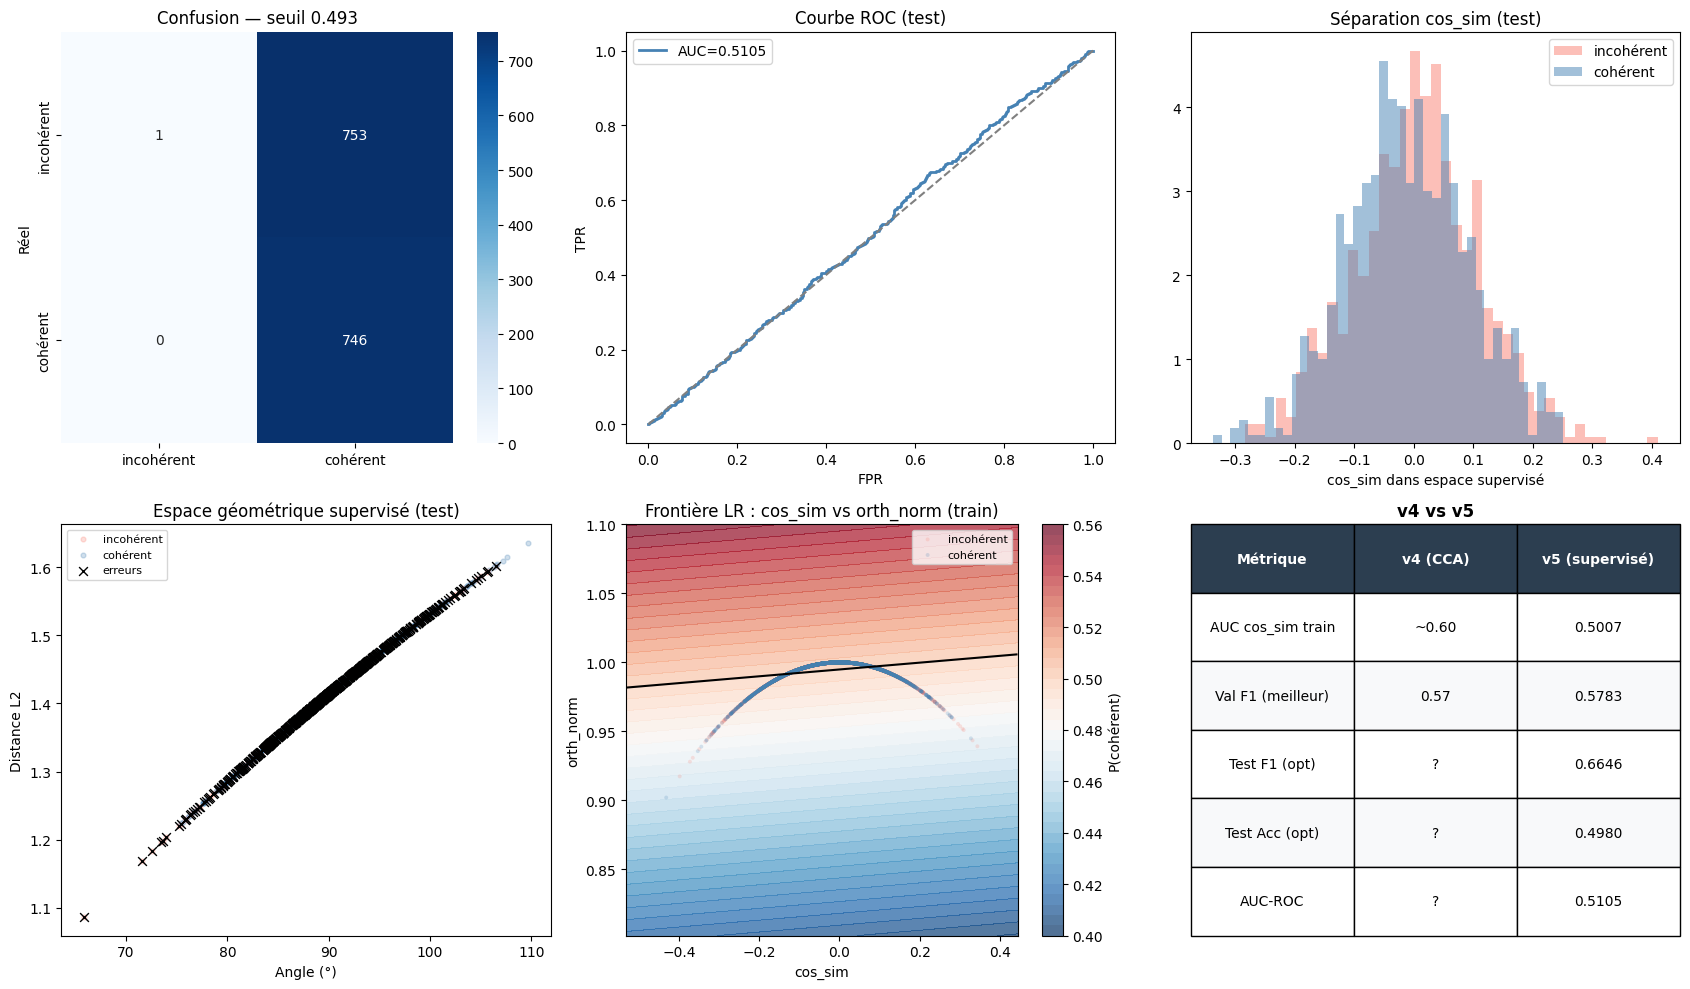

In [14]:
# ═══════════════════════════════════════════════════════════════════
# Cell 14 — Visualisations finales
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['incohérent','cohérent'],
            yticklabels=['incohérent','cohérent'])
axes[0,0].set_title(f'Confusion — seuil {THRESH:.3f}'); axes[0,0].set_ylabel('Réel')

# ROC
if proba_te is not None:
    fpr, tpr, _ = roc_curve(y_test, proba_te)
    axes[0,1].plot(fpr, tpr, 'steelblue', lw=2, label=f'AUC={auc:.4f}')
    axes[0,1].plot([0,1],[0,1],'--',color='gray')
    axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR')
    axes[0,1].set_title('Courbe ROC (test)'); axes[0,1].legend()

# Distribution cos_sim sur test
cos_te = Xg_te[:, IDX['cos_sim']]
axes[0,2].hist(cos_te[y_test==0], bins=40, alpha=0.5, color='salmon', label='incohérent', density=True)
axes[0,2].hist(cos_te[y_test==1], bins=40, alpha=0.5, color='steelblue', label='cohérent', density=True)
axes[0,2].set_xlabel('cos_sim dans espace supervisé'); axes[0,2].set_title('Séparation cos_sim (test)')
axes[0,2].legend()

# Scatter angle vs distance sur test avec erreurs
ang_te = Xg_te[:, IDX['angle_deg']]
dis_te = Xg_te[:, IDX['d_l2']]
err    = y_pred != y_test
for lbl in [0,1]:
    mask = y_test==lbl
    axes[1,0].scatter(ang_te[mask], dis_te[mask], c=colors[lbl],
                      label=labels_cls[lbl], alpha=0.25, s=12)
axes[1,0].scatter(ang_te[err], dis_te[err], marker='x', s=40, c='black', lw=1, label='erreurs')
axes[1,0].set_xlabel('Angle (°)'); axes[1,0].set_ylabel('Distance L2')
axes[1,0].set_title('Espace géométrique supervisé (test)'); axes[1,0].legend(fontsize=8)

# Frontière 2D (cos_sim vs orth_norm)
X2 = Xg_tr[:, [IDX['cos_sim'], IDX['orth_norm']]]
sc2 = StandardScaler(); X2s = sc2.fit_transform(X2)
lr2 = LogisticRegression(C=1, class_weight='balanced', max_iter=2000, random_state=42)
lr2.fit(X2s, y_train)

xr = np.linspace(X2[:,0].min()-0.1, X2[:,0].max()+0.1, 300)
yr = np.linspace(X2[:,1].min()-0.1, X2[:,1].max()+0.1, 300)
xx, yy = np.meshgrid(xr, yr)
Z = lr2.predict_proba(sc2.transform(np.c_[xx.ravel(), yy.ravel()]))[:,1].reshape(xx.shape)

cf = axes[1,1].contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.7)
axes[1,1].contour(xx, yy, Z, levels=[0.5], colors='black', lw=2)
plt.colorbar(cf, ax=axes[1,1], label='P(cohérent)')
for lbl in [0,1]:
    mask = y_train==lbl
    axes[1,1].scatter(X2[mask,0], X2[mask,1], c=colors[lbl],
                      alpha=0.2, s=8, edgecolors='none', label=labels_cls[lbl])
axes[1,1].set_xlabel('cos_sim'); axes[1,1].set_ylabel('orth_norm')
axes[1,1].set_title('Frontière LR : cos_sim vs orth_norm (train)')
axes[1,1].legend(fontsize=8)

# Comparaison v4 vs v5 (tableau)
axes[1,2].axis('off')
table_data = [
    ['Métrique', 'v4 (CCA)', 'v5 (supervisé)'],
    ['AUC cos_sim train', '~0.60', f'{roc_auc_score(y_train, Xg_tr[:,IDX["cos_sim"]]):.4f}'],
    ['Val F1 (meilleur)', '0.57', f'{best["val_f1"]:.4f}'],
    ['Test F1 (opt)', '?', f'{f1_opt:.4f}'],
    ['Test Acc (opt)', '?', f'{acc_opt:.4f}'],
    ['AUC-ROC', '?', f'{auc:.4f}'],
]
table = axes[1,2].table(cellText=table_data[1:], colLabels=table_data[0],
                          cellLoc='center', loc='center',
                          bbox=[0,0,1,1])
table.auto_set_font_size(False); table.set_fontsize(10)
for (r,c), cell in table.get_celld().items():
    if r == 0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', weight='bold')
    elif r % 2 == 0: cell.set_facecolor('#f8f9fa')
axes[1,2].set_title('v4 vs v5', fontweight='bold')

plt.tight_layout()
plt.savefig('v5_final_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

LR scalaires seuls — Val F1=0.4912  Acc=0.5013

Règle de décision (coefficients LR sur features géométriques) :
Rang Feature                    Coef Effet
-------------------------------------------------------
1    pearson_r                0.1204   P(cohérent) ↑
2    magdiff_mean            -0.0884   P(cohérent) ↓
3    magdiff_std              0.0736   P(cohérent) ↑
4    absdiff_std             -0.0524   P(cohérent) ↓
5    diff_std                 0.0357   P(cohérent) ↑
6    d_linf                  -0.0315   P(cohérent) ↓
7    angle_rad                0.0221   P(cohérent) ↑
8    angle_deg                0.0221   P(cohérent) ↑
9    d_l2                     0.0208   P(cohérent) ↑
10   ent_ratio               -0.0190   P(cohérent) ↓
11   diff_min                -0.0177   P(cohérent) ↓
12   orth_norm                0.0173   P(cohérent) ↑
13   product_std             -0.0145   P(cohérent) ↓
14   d_cos                    0.0134   P(cohérent) ↑
15   cos_sim                 -0.0134   P(cohére

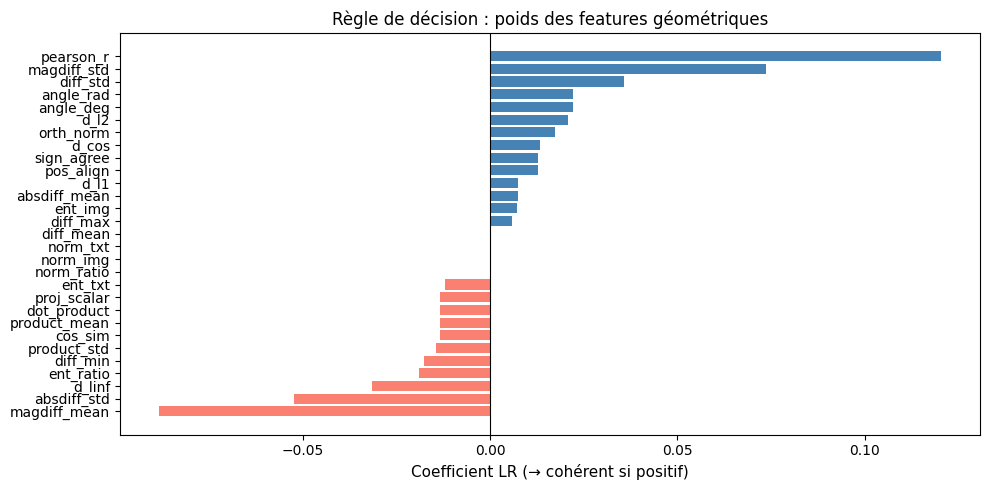

In [15]:
# ═══════════════════════════════════════════════════════════════════
# Cell 15 — Règle de décision interprétable
#
# Si LR est le meilleur modèle sur les scalaires :
# on peut lire directement la règle de décision en termes
# d'angle et de distance.
# ═══════════════════════════════════════════════════════════════════
# Modèle LR sur scalaires seuls
lr_scalaires = LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=42)
lr_scalaires.fit(Xs_tr, y_train)
yp_sc = lr_scalaires.predict(Xs_va)
print(f'LR scalaires seuls — Val F1={f1_score(y_val,yp_sc):.4f}  Acc={accuracy_score(y_val,yp_sc):.4f}')

coef = lr_scalaires.coef_[0]
top15 = np.argsort(np.abs(coef))[::-1][:15]

print('\nRègle de décision (coefficients LR sur features géométriques) :')
print(f'{"Rang":<4} {"Feature":<18} {"Coef":>12} {"Effet"}')
print('-'*55)
for rank, idx in enumerate(top15):
    name = SCALAR_NAMES[idx]
    c    = coef[idx]
    effet = 'P(cohérent) ↑' if c > 0 else 'P(cohérent) ↓'
    print(f'{rank+1:<4} {name:<18} {c:>12.4f}   {effet}')

print()
print('Interprétation de la règle apprise :')
for name in ['cos_sim','angle_deg','d_l2','orth_norm','pearson_r','pos_align','sign_agree']:
    idx = IDX[name]
    c   = coef[idx]
    if abs(c) > 0.01:
        if c > 0:
            print(f'  + {name} élevé  → plus probablement COHÉRENT   (coef={c:+.3f})')
        else:
            print(f'  + {name} faible → plus probablement COHÉRENT   (coef={c:+.3f})')

# Visualisation des coefficients
fig, ax = plt.subplots(figsize=(10, 5))
sorted_idx = np.argsort(coef)
ax.barh([SCALAR_NAMES[i] for i in sorted_idx],
         coef[sorted_idx],
         color=['salmon' if c < 0 else 'steelblue' for c in coef[sorted_idx]])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient LR (→ cohérent si positif)', fontsize=11)
ax.set_title('Règle de décision : poids des features géométriques', fontsize=12)
plt.tight_layout()
plt.savefig('v5_decision_rule.png', dpi=120, bbox_inches='tight')
plt.show()

In [16]:
# ═══════════════════════════════════════════════════════════════════
# Cell 16 — Sauvegarde
# ═══════════════════════════════════════════════════════════════════
import joblib

joblib.dump(sbp,          'v5_projector.pkl')
joblib.dump(MODEL,        'v5_model.pkl')
joblib.dump(sc_geo,       'v5_scaler_geo.pkl')
joblib.dump(pca_i,        'v5_pca_img.pkl')
joblib.dump(svd_t,        'v5_svd_txt.pkl')
joblib.dump(sc_i,         'v5_sc_img.pkl')
joblib.dump(sc_t,         'v5_sc_txt.pkl')
joblib.dump(vt_i,         'v5_vt_img.pkl')
joblib.dump(vt_t,         'v5_vt_txt.pkl')
joblib.dump(tfidf,        'v5_tfidf.pkl')
joblib.dump({'threshold': THRESH, 'best_clf': best['clf'],
             'D_img': D_img, 'K_proj': K_PROJ}, 'v5_config.pkl')

print('═'*55)
print('  PIPELINE v5 — Géométrie supervisée')
print('─'*55)
print(f'  Test Acc : {acc_opt:.4f}')
print(f'  Test F1  : {f1_opt:.4f}')
print(f'  AUC-ROC  : {auc:.4f}')
print('─'*55)
print('  Architecture :')
print('  img_feats ──┐')
print('               ├─ PCA ─┬─ LDA supervisée (y) ─┐')
print('  txt_feats ──┘        │    W_img, W_txt        │')
print('                       └──────────────────────── │')
print('                    v_img = img @ W_img          │')
print('                    v_txt = txt @ W_txt          │')
print('                    angle θ, dist d, cos_sim ... │')
print(f'                    classifieur {best["clf"]}  seuil {THRESH:.3f}')
print('═'*55)
print('Sauvegarde OK.')

═══════════════════════════════════════════════════════
  PIPELINE v5 — Géométrie supervisée
───────────────────────────────────────────────────────
  Test Acc : 0.4980
  Test F1  : 0.6646
  AUC-ROC  : 0.5105
───────────────────────────────────────────────────────
  Architecture :
  img_feats ──┐
               ├─ PCA ─┬─ LDA supervisée (y) ─┐
  txt_feats ──┘        │    W_img, W_txt        │
                       └──────────────────────── │
                    v_img = img @ W_img          │
                    v_txt = txt @ W_txt          │
                    angle θ, dist d, cos_sim ... │
                    classifieur SVM-RBF  seuil 0.493
═══════════════════════════════════════════════════════
Sauvegarde OK.
